# 02 - Preprocessing: reproduzierbare Feature-Pipeline

Erzeugt aus fÃ¼nf Quellen einen **standortbezogenen, stÃ¼ndlichen** Feature-Datensatz
fÃ¼r Day-Ahead-Forecasting (NB03) und XAI (NB05). Die gesamte Logik liegt in
`src/data/preprocessing.py`.

| Quelle | Inhalt | Zeitzone | AuflÃ¶sung | Oracle? |
|---|---|---|---|---|
| Produktion (SCADA) | `power`, `wind_speed_obs` | Europe/Berlin | 10 min â†’ 1 h | â€” |
| ERA5 (Copernicus CDS) | Wind 100/10 m, T2m, Druck, TCC | UTC | 1 h | **Ja** |
| Solar (pvlib) | Zenitwinkel, Azimut, Clear-Sky | berechnet | 1 h | â€” |
| CAMS (Copernicus ADS) | GHI/DNI/DHI Meteosat | UTC | 1 h | â€” |
| **NWP (Open-Meteo)** | **ECMWF IFS HRES Forecast** | **UTC** | **1 h** | **Nein** |

> **ERA5 = Perfect-Forecast-Baseline (Oracle):** ERA5 ist Reanalyse, keine operative
> NWP-Prognose. Modelle mit ERA5-Features quantifizieren die **obere Leistungsgrenze**.
> FÃ¼r die operative Modellierung (Gruppen K-N) werden stattdessen **ECMWF IFS HRES
> Forecasts** via Open-Meteo verwendet (ab 2017-01-01, kostenlos, kein Oracle-Problem).

**Master-Zeitraster:** stÃ¼ndlich, naiv-lokal; ERA5/CAMS/NWP per UTCâ†’Europe/Berlin gemappt.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
from src.data import preprocessing as pp
importlib.reload(pp)

pd.set_option("display.width", 160)
print("Standorte:", list(pp.SITES))
print("Produktions-Zeitzone (Annahme):", pp.PRODUCTION_TZ)
print("Wetterordner:", pp.WEATHER_DIR)

Standorte: ['Schonungen', 'Schwanfeld', 'Trabelsdorf', 'Obbach']
Produktions-Zeitzone (Annahme): Europe/Berlin
Wetterordner: C:\Users\felix\Documents\AI1\wind_bidding_project\data\raw\weather


## 1 Â· Produktion laden & robust bereinigen
`load_and_clean_production()`: numerische Bereinigung (Komma-Dezimal, Leerstrings,
Mischformate), Duplikat-/PlausibilitÃ¤tsprÃ¼fung, dann Stundenmittel **pro Standort**.

> Hinweis: lÃ¤dt alle SCADA-Excel-Dateien (~280) - das dauert einige Minuten.

In [2]:
prod = pp.load_and_clean_production()                 # 10-min, bereinigt, lang
prod_hourly = pp.aggregate_to_hourly_per_site(prod)   # Stundenmittel je Standort
print(prod_hourly.shape)
prod_hourly.head(3)


Obbach: 260 Datei(en)
  Lade: 202104_WEA 1_MeterReading_OperationalData_WindTurbine.xlsx


  Lade: 202104_WEA 2_MeterReading_OperationalData_WindTurbine.xlsx


  Lade: 202104_WEA 3_MeterReading_OperationalData_WindTurbine.xlsx


  Lade: 202104_WEA 4_MeterReading_OperationalData_WindTurbine.xlsx


  Lade: 202104_WEA 5_MeterReading_OperationalData_WindTurbine.xlsx


...


Gesamt: 5,612,959 Zeilen


Standorte: ['Obbach', 'Schonungen', 'Schwanfeld', 'Trabelsdorf']
Zeitraum:  2014-01-02 00:00:00 bis 2025-09-01 00:00:00


Produktion bereinigt: 5,612,959 -> 1,747,220 Zeilen (4 Standorte)


(297244, 5)


,site,timestamp,power,wind_speed_obs,energy_mwh
0,Obbach,2021-04-14 00:00:00,586.821667,5.315000,0.586822
1,Obbach,2021-04-14 01:00:00,237.175000,4.183333,0.237175
2,Obbach,2021-04-14 02:00:00,196.301667,4.090000,0.196302


## 2 Â· ERA5-Feature-Block
`build_era5_features()`: robuste Variablenerkennung, bilineare Interpolation auf die
exakte Anlagenkoordinate, Ableitung von ws/wd (100 m & 10 m, meteorologische
Konvention), Wind-Shear, UTCâ†’lokal.

## 2 Â· Wetterdaten: NWP-Features (ECMWF IFS HRES)
`build_nwp_features()`: liest `data/raw/nwp/nwp_<standort>.csv`, konvertiert Einheiten (Â°Câ†’K, hPaâ†’Pa, %â†’0-1),
und erzeugt Ableitungen wie Wind-Shear und zyklische Kodierung der Windrichtung.

In [3]:
nwp = pp.build_nwp_features(verbose=True)
print(f"\nShape: {nwp.shape}")
print(f"Zeitraum: {nwp['timestamp'].min()} â†’ {nwp['timestamp'].max()}")

  Schonungen: 75,952 Stunden NWP geladen (2017-01-01 .. 2025-09-01)
  Schwanfeld: 75,952 Stunden NWP geladen (2017-01-01 .. 2025-09-01)


  Trabelsdorf: 75,952 Stunden NWP geladen (2017-01-01 .. 2025-09-01)
  Obbach: 75,952 Stunden NWP geladen (2017-01-01 .. 2025-09-01)

Shape: (303808, 15)
Zeitraum: 2017-01-01 01:00:00 â†’ 2025-09-01 01:00:00


## 3 Â· Solar-/astronomischer Block (pvlib)
`build_solar_features()`: Zenitwinkel, Azimut, is_day und Clear-Sky GHI/DNI/DHI (pvlib
Ineichen-Modell) - berechnet aus Koordinate + Zeit (kein Download, keine Satellitendaten).
Die pvlib-Clear-Sky-Werte dienen als Fallback und fÃ¼r Gruppen E-H; die echten Satellitenwerte
kommen aus CAMS (Abschnitt 4).

In [4]:
master_idx = pp.harmonize_timestamps(prod_hourly)   # stÃ¼ndl. lokaler Master-Index
solar = pp.build_solar_features(master_idx)
print(solar.shape)
solar.head(3)

(408872, 8)


,timestamp,site,solar_zenith,solar_azimuth,clearsky_ghi,clearsky_dni,clearsky_dhi,is_day
0,2014-01-02 00:00:00,Schonungen,152.540576,348.783631,0.0,0.0,0.0,0
1,2014-01-02 01:00:00,Schonungen,151.905356,18.636757,0.0,0.0,0.0,0
2,2014-01-02 02:00:00,Schonungen,146.853384,44.090171,0.0,0.0,0.0,0


## 4 Â· CAMS-Satellitendaten-Block (Copernicus ADS)
`build_cams_features()`: Meteosat GHI/DNI/DHI Messungen (Copernicus ADS CAMS),
Clear-Sky-Index fÃ¼r aktuelle BewÃ¶lkung. Optional: Wenn keine Dateien vorhanden,
`pp.download_cams_data()` aufrufen.

In [5]:
cams = pp.build_cams_features(verbose=True)
if cams is not None:
    print(f"\nShape: {cams.shape}")
    print(f"Zeitraum: {cams['timestamp'].min()} â†’ {cams['timestamp'].max()}")
else:
    print("Keine CAMS-Daten vorhanden - optional fÃ¼r diese Analyse")

  Schonungen: 75,952 Stunden CAMS geladen (2017-01-01 .. 2025-09-01)


  Schwanfeld: 75,952 Stunden CAMS geladen (2017-01-01 .. 2025-09-01)


  Trabelsdorf: 75,952 Stunden CAMS geladen (2017-01-01 .. 2025-09-01)


  Obbach: 75,952 Stunden CAMS geladen (2017-01-01 .. 2025-09-01)

Shape: (303808, 9)
Zeitraum: 2017-01-01 01:00:00 â†’ 2025-09-01 01:00:00


## 5 Â· Zeitachsen harmonisieren, mergen & zyklisch kodieren
Merge der vier BlÃ¶cke pro `[site, timestamp]` (Produktion = Master, left-join),
danach Kalender- und zyklische Wind-/Zeit-Features.

In [6]:
merged = pp.merge_feature_blocks(prod_hourly, era5=None, solar=solar, cams=cams, nwp=nwp)
merged = pp.add_cyclic_features(merged)
print(merged.shape)
print("Spalten:", list(merged.columns))
merged.head(3)

(297244, 38)
Spalten: ['site', 'timestamp', 'power', 'wind_speed_obs', 'energy_mwh', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni', 'clearsky_dhi', 'is_day', 'cams_ghi', 'cams_dni', 'cams_dhi', 'cams_clearsky_ghi', 'cams_clearsky_dni', 'cams_clearsky_dhi', 'cams_clearsky_index', 'nwp_ws100', 'nwp_wd100', 'nwp_ws10', 'nwp_wd10', 'nwp_temp2m', 'nwp_surface_pressure', 'nwp_total_cloud_cover', 'nwp_wind_shear_diff', 'nwp_wind_shear_ratio', 'nwp_sin_wd100', 'nwp_cos_wd100', 'nwp_sin_wd10', 'nwp_cos_wd10', 'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


,site,timestamp,power,wind_speed_obs,energy_mwh,solar_zenith,solar_azimuth,clearsky_ghi,clearsky_dni,clearsky_dhi,...,nwp_cos_wd100,nwp_sin_wd10,nwp_cos_wd10,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,Obbach,2021-04-14 00:00:00,586.821667,5.315000,0.586822,118.026700,337.506508,0.0,0.0,0.0,...,0.945519,-0.656059,0.754710,0,2,4,0.000000,1.000000,0.974928,-0.222521
1,Obbach,2021-04-14 01:00:00,237.175000,4.183333,0.237175,120.362997,354.264478,0.0,0.0,0.0,...,0.939693,-0.615661,0.788011,1,2,4,0.258819,0.965926,0.974928,-0.222521
2,Obbach,2021-04-14 02:00:00,196.301667,4.090000,0.196302,119.872996,11.380804,0.0,0.0,0.0,...,0.990268,-0.453990,0.891007,2,2,4,0.500000,0.866025,0.974928,-0.222521


## 5 Â· NWP-Forecast-Block (Open-Meteo ECMWF IFS HRES)
`build_nwp_features()`: liest `data/raw/nwp/nwp_<standort>.csv` â€” archivierte ECMWF IFS HRES
Forecast-LÃ¤ufe ab 2017-01-01 (Open-Meteo Historical Forecast API, kostenlos, kein API-Key).
Gleiche Attribute wie ERA5 (`nwp_ws100`, `nwp_wd100`, â€¦), Einheiten identisch (K, Pa, 0-1).
**Kein Oracle-Problem** â€” das sind echte Forecasts wie zum Gebotszeitpunkt verfÃ¼gbar.

In [7]:
LAG_COLS = ["energy_mwh", "wind_speed_obs",
            "ws100", "sin_wd100", "cos_wd100",          # ERA5 (oracle)
            "nwp_ws100", "nwp_sin_wd100", "nwp_cos_wd100",  # NWP (operativ)
            "temp2m", "nwp_temp2m",
            "surface_pressure", "total_cloud_cover",
            "clearsky_ghi", "cams_ghi", "cams_clearsky_index"]
LAG_COLS = [c for c in LAG_COLS if c in merged.columns]
df_model = pp.build_lag_features(merged, LAG_COLS)
print("Basis:", merged.shape, "-> Modell (mit Lags/Rolling):", df_model.shape)
[c for c in df_model.columns if "lag" in c or "roll" in c][:12]

Basis: (297244, 38) -> Modell (mit Lags/Rolling): (297244, 146)


C:\Users\felix\Documents\AI1\wind_bidding_project\src\data\preprocessing.py:733: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_lag{L}h"] = g[c].shift(L)
C:\Users\felix\Documents\AI1\wind_bidding_project\src\data\preprocessing.py:733: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_lag{L}h"] = g[c].shift(L)
C:\Users\felix\Documents\AI1\wind_bidding_project\src\data\preprocessing.py:733: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

['energy_mwh_lag1h',
 'energy_mwh_lag2h',
 'energy_mwh_lag3h',
 'energy_mwh_lag6h',
 'energy_mwh_lag12h',
 'energy_mwh_lag24h',
 'energy_mwh_rollmean3h',
 'energy_mwh_rollstd3h',
 'energy_mwh_rollmean6h',
 'energy_mwh_rollstd6h',
 'energy_mwh_rollmean24h',
 'energy_mwh_rollstd24h']

## 6 Â· Lags & Rolling Features
Standard-Lags 1/2/3/6/12/24 h und Rolling-Mean/Std 3/6/24 h (je Standort, jeweils
um 1 h verschoben â†’ kein Leakage). Basis-Spalten inkl. CAMS-Features.

In [8]:
LAG_COLS = ["energy_mwh", "wind_speed_obs", "ws100", "sin_wd100", "cos_wd100",
            "temp2m", "surface_pressure", "total_cloud_cover",
            "clearsky_ghi", "cams_ghi", "cams_clearsky_index"]
# Nur Spalten nehmen die tatsÃ¤chlich vorhanden sind (cams optional)
LAG_COLS = [c for c in LAG_COLS if c in merged.columns]
df_model = pp.build_lag_features(merged, LAG_COLS)
print("Basis:", merged.shape, "-> Modell (mit Lags/Rolling):", df_model.shape)
[c for c in df_model.columns if "lag" in c or "roll" in c][:12]

Basis: (297244, 38) -> Modell (mit Lags/Rolling): (297244, 98)


['energy_mwh_lag1h',
 'energy_mwh_lag2h',
 'energy_mwh_lag3h',
 'energy_mwh_lag6h',
 'energy_mwh_lag12h',
 'energy_mwh_lag24h',
 'energy_mwh_rollmean3h',
 'energy_mwh_rollstd3h',
 'energy_mwh_rollmean6h',
 'energy_mwh_rollstd6h',
 'energy_mwh_rollmean24h',
 'energy_mwh_rollstd24h']

## 7 Â· DatenqualitÃ¤t & Abdeckung
Pro Standort: Zeitraum, Zeilen, Fehlanteil je Block.

In [9]:
blocks = {"prod": pp.PRODUCTION_FEATURES, "era5": pp.ERA5_FULL_FEATURES,
          "solar": pp.SOLAR_FEATURES, "cams": pp.CAMS_FEATURES}
# Nur BlÃ¶cke prÃ¼fen die vorhanden sind
blocks = {k: v for k, v in blocks.items() if any(c in merged.columns for c in v)}
qc = pp.run_data_quality_checks(merged, blocks)
display(qc)

core = ["energy_mwh", "ws100", "ws100_lag24h", "ws100_rollmean24h"]
core = [c for c in core if c in df_model.columns]
n_full = df_model.dropna(subset=core).shape[0]
print(f"Modellzeilen vollstÃ¤ndig (Kernspalten): {n_full:,} / {len(df_model):,} "
      f"({100*n_full/max(1,len(df_model)):.1f} %)")

,site,von,bis,zeilen,na_prod_%,na_solar_%,na_cams_%
0,Obbach,2021-04-14 00:00:00,2025-09-01 00:00:00,38425,2.8,0.0,6.4
1,Schonungen,2014-01-02 00:00:00,2025-08-31 23:00:00,102240,3.8,0.0,30.5
2,Schwanfeld,2016-03-31 11:00:00,2025-08-31 23:00:00,82573,0.3,0.0,14.0
3,Trabelsdorf,2017-03-23 10:00:00,2025-08-31 23:00:00,74006,0.9,0.0,6.4


Modellzeilen vollstÃ¤ndig (Kernspalten): 291,416 / 297,244 (98.0 %)


## 8 Â· Explorative Validierung
Power-Curve, Korrelationen, SaisonalitÃ¤t, Standortvergleich und Solar/CAMS-Features.

In [10]:
blocks = {"prod": pp.PRODUCTION_FEATURES, "era5": pp.ERA5_FULL_FEATURES,
          "solar": pp.SOLAR_FEATURES}
qc = pp.run_data_quality_checks(merged, blocks)
display(qc)

# Zeilenverlust durch Lags/Rolling (vollstÃ¤ndige Modellzeilen)
core = ["energy_mwh", "ws100", "ws100_lag24h", "ws100_rollmean24h"]
core = [c for c in core if c in df_model.columns]
n_full = df_model.dropna(subset=core).shape[0]
print(f"Modellzeilen vollstÃ¤ndig (Kernspalten): {n_full:,} / {len(df_model):,} "
      f"({100*n_full/max(1,len(df_model)):.1f} %)")

,site,von,bis,zeilen,na_prod_%,na_solar_%
0,Obbach,2021-04-14 00:00:00,2025-09-01 00:00:00,38425,2.8,0.0
1,Schonungen,2014-01-02 00:00:00,2025-08-31 23:00:00,102240,3.8,0.0
2,Schwanfeld,2016-03-31 11:00:00,2025-08-31 23:00:00,82573,0.3,0.0
3,Trabelsdorf,2017-03-23 10:00:00,2025-08-31 23:00:00,74006,0.9,0.0


Modellzeilen vollstÃ¤ndig (Kernspalten): 291,416 / 297,244 (98.0 %)

# Korrelationen der finalen Features (inkl. CAMS)
corr_cols = (pp.PRODUCTION_FEATURES + pp.ERA5_FULL_FEATURES +
             pp.SOLAR_FEATURES + pp.CAMS_FEATURES)
corr_cols = [c for c in corr_cols if c in merged.columns]
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(merged[corr_cols].corr(), annot=False, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Korrelationsmatrix der Feature-BlÃ¶cke (ERA5 + Solar/pvlib + CAMS)")
plt.tight_layout(); plt.show()

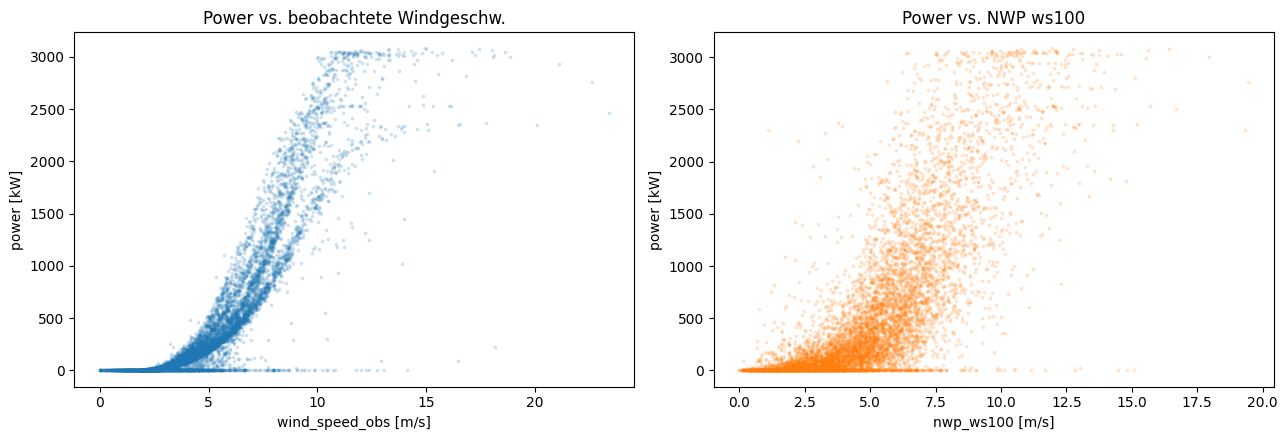

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
s = merged.dropna(subset=["power", "wind_speed_obs"]).sample(min(8000, len(merged)), random_state=0)
ax[0].scatter(s["wind_speed_obs"], s["power"], s=3, alpha=0.15)
ax[0].set(title="Power vs. beobachtete Windgeschw.", xlabel="wind_speed_obs [m/s]", ylabel="power [kW]")
s2 = merged.dropna(subset=["power", "nwp_ws100"]).sample(min(8000, len(merged)), random_state=0)
ax[1].scatter(s2["nwp_ws100"], s2["power"], s=3, alpha=0.15, color="#ff7f0e")
ax[1].set(title="Power vs. NWP ws100", xlabel="nwp_ws100 [m/s]", ylabel="power [kW]")
plt.tight_layout(); plt.show()

In [12]:
groups = pp.feature_groups()
# Operative Gruppen: K-N (NWP, kein Oracle). A-J (ERA5, nur Benchmark).
operative = {k: v for k, v in groups.items() if k.startswith(('K', 'L', 'M', 'N'))}
for name, feats in operative.items():
    avail = [f for f in feats if f in merged.columns]
    cams_tag = " [CAMS]" if any("cams" in f for f in avail) else ""
    print(f"{name:30s} {len(avail):2d} Features{cams_tag}  ->  {avail[:4]} ...")

K_prod_nwpwind                 11 Features  ->  ['energy_mwh', 'wind_speed_obs', 'nwp_ws100', 'nwp_wd100'] ...
L_prod_nwpfull                 20 Features  ->  ['energy_mwh', 'wind_speed_obs', 'nwp_ws100', 'nwp_wd100'] ...
M_prod_nwp_solar               26 Features  ->  ['energy_mwh', 'wind_speed_obs', 'nwp_ws100', 'nwp_wd100'] ...
N_prod_nwp_cams                30 Features [CAMS]  ->  ['energy_mwh', 'wind_speed_obs', 'nwp_ws100', 'nwp_wd100'] ...


## 9 Â· Feature-Gruppen A-J (Ablation / XAI)
Gruppen A-H ohne CAMS (reproduzierbar ohne ADS-Download), I-J mit CAMS-Satellitendaten.

In [13]:
groups = pp.feature_groups()
for name, feats in groups.items():
    avail = [f for f in feats if f in merged.columns]
    cams_tag = " [CAMS]" if any("cams" in f for f in avail) else ""
    print(f"{name:30s} {len(avail):2d} Features{cams_tag}  ->  {avail[:4]} ...")

A_production                    7 Features  ->  ['energy_mwh', 'wind_speed_obs', 'hour_sin', 'hour_cos'] ...
B_prod_era5wind                 7 Features  ->  ['energy_mwh', 'wind_speed_obs', 'hour_sin', 'hour_cos'] ...
C_prod_era5full                 7 Features  ->  ['energy_mwh', 'wind_speed_obs', 'hour_sin', 'hour_cos'] ...
D_era5only                      5 Features  ->  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'] ...
E_prod_solar                   13 Features  ->  ['energy_mwh', 'wind_speed_obs', 'solar_zenith', 'solar_azimuth'] ...
F_prod_era5_solar              13 Features  ->  ['energy_mwh', 'wind_speed_obs', 'solar_zenith', 'solar_azimuth'] ...
G_solaronly                    11 Features  ->  ['solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni'] ...
H_era5_solar_noprod            11 Features  ->  ['solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni'] ...
I_prod_era5_cams               17 Features [CAMS]  ->  ['energy_mwh', 'wind_speed_obs', 'solar_zenith'

## 10 Â· Export
- `features_base_all_sites.csv` - Basis ohne Lags (inkl. CAMS-Spalten)
- `features_model_all_sites.csv` - mit Lags/Rolling (inkl. cams_ghi_lag*, cams_clearsky_index_lag*)
- `features_site_<site>.csv` - pro Standort
- `feature_documentation.csv` - Feature-Doku (Quelle, Einheit, Gruppe)

## 8 Â· Feature-Gruppen A-H (Ablation / XAI)
Explizite Gruppen fÃ¼r Modellvergleich und SHAP-Analysen in NB03/NB05.

## Konsistenz mit NB03 / NB05
Forecasting (NB03) und XAI (NB05) sollen dieselben Funktionen aus
`src/data/preprocessing.py` nutzen statt Feature-Logik zu duplizieren:
`build_era5_features`, `build_solar_features`, `build_cams_features`,
`add_cyclic_features`, `build_lag_features`, `feature_groups`.

**CAMS-Tipp fÃ¼r NB03:** Der Clear-Sky-Index `cams_clearsky_index` ist ein starker
Proxy fÃ¼r aktuelle BewÃ¶lkung (Wert nahe 0 = bedeckt, ~1 = wolkenlos). Lags davon
(z. B. `cams_clearsky_index_lag1h`) kÃ¶nnen NWP-Wolkenfehler teilweise kompensieren.

## 9 Â· Export
- `features_base_all_sites.csv` - Basis ohne Lags
- `features_model_all_sites.csv` - mit Lags/Rolling
- `features_site_<site>.csv` - pro Standort
- `feature_documentation.csv` - Feature-Doku

> Das bestehende `final_dataset.csv` (Portfolio, 3 Standorte) wird **nicht** Ã¼berschrieben,
> damit NB03 unverÃ¤ndert lauffÃ¤hig bleibt, bis es auf den Standort-Datensatz umgestellt wird.

In [14]:
written = pp.export_feature_sets(merged, df_model, per_site=True)
for k, v in written.items():
    print(f"{k:18s} -> {v.name}")
display(pp.build_feature_documentation())

base               -> features_base_all_sites.csv
model              -> features_model_all_sites.csv
site_Obbach        -> features_site_Obbach.csv
site_Schonungen    -> features_site_Schonungen.csv
site_Schwanfeld    -> features_site_Schwanfeld.csv
site_Trabelsdorf   -> features_site_Trabelsdorf.csv
doc                -> feature_documentation.csv


,feature,beschreibung,quelle,einheit,gruppe
0,power,Mittlere Anlagenleistung (Stunde),production,kW,target
1,energy_mwh,Stundenenergie (power/1000),production,MWh,A-F
2,wind_speed_obs,Gemessene Windgeschw. (SCADA),production,m/s,A-F
3,ws100,ERA5 Windgeschw. 100 m,ERA5,m/s,"B,C,D,F,H"
4,wd100,ERA5 Windrichtung 100 m,derived,deg,"B,C,D,F,H"
5,sin_wd100/cos_wd100,Zyklische Windrichtung 100 m,derived,-,"B,C,D,F,H"
6,ws10/wd10,ERA5 Wind 10 m + Richtung,ERA5/derived,m/s/deg,"C,D,F,H"
7,temp2m,ERA5 2m-Temperatur,ERA5,K,"C,D,F,H"
8,surface_pressure,ERA5 Oberflaechendruck,ERA5,Pa,"C,D,F,H"
9,total_cloud_cover,ERA5 Gesamtbedeckungsgrad (TCC),ERA5,0-1,"C,D,F,H"


## Konsistenz mit NB03 / NB05
Forecasting (NB03) und XAI (NB05) sollen langfristig dieselben Funktionen aus
`src/data/preprocessing.py` nutzen statt die Feature-Logik zu duplizieren:
`build_era5_features`, `build_solar_features`, `add_cyclic_features`,
`build_lag_features`, `feature_groups`. Die Gate-Close-Day-Ahead-Features in NB03
lassen sich direkt aus den hier erzeugten Basisspalten (`ws100`, `energy_mwh`,
`temp2m`, â€¦) ableiten - die Benennung ist dafÃ¼r vorbereitet.